In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("tips.csv")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
print(df.shape)

(244, 7)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


In [8]:
df.describe().round(1)

,total_bill,tip,size
count,244.0,244.0,244.0
mean,19.8,3.0,2.6
std,8.9,1.4,1.0
min,3.1,1.0,1.0
25%,13.3,2.0,2.0
50%,17.8,2.9,2.0
75%,24.1,3.6,3.0
max,50.8,10.0,6.0


In [ ]:
print(df["sex"].value_counts()) 
print("Maximum tip:", df["tip"].max())
print("Minimum tip:", df["tip"].min())

sex
Male      157
Female     87
Name: count, dtype: int64
Maximum tip: 10.0
Minimum tip: 1.0


In [26]:
print("Maximum tip (Day Wise)", df.groupby("day")["tip"].max())
print("\nMinimum tip (Day Wise)", df.groupby("day")["tip"].min())

Maximum tip (Day Wise) day
Fri      4.73
Sat     10.00
Sun      6.50
Thur     6.70
Name: tip, dtype: float64

Minimum tip (Day Wise) day
Fri     1.00
Sat     1.00
Sun     1.01
Thur    1.25
Name: tip, dtype: float64


In [ ]:
print(df.groupby("sex")["tip"].mean().round(1))
print(df.groupby("smoker")["tip"].max().round(1))
print(df.groupby("time")["tip"].max().round(1))

sex
Female    2.8
Male      3.1
Name: tip, dtype: float64
smoker
No      9.0
Yes    10.0
Name: tip, dtype: float64
time
Dinner    10.0
Lunch      6.7
Name: tip, dtype: float64


In [46]:
df["total_amount"] = df["total_bill"] + df["tip"]
print(df["total_amount"].sort_values(ascending=False).head())
print(df.shape)

170    60.81
212    57.33
59     55.00
156    53.17
182    48.85
Name: total_amount, dtype: float64
(244, 8)


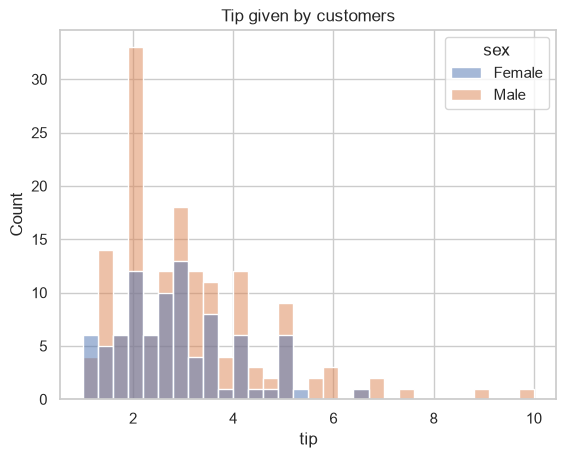

In [51]:
sns.set_theme(style="whitegrid")
sns.histplot(data=df, x="tip", bins=30, hue="sex")
plt.title("Tip given by customers")
plt.show()

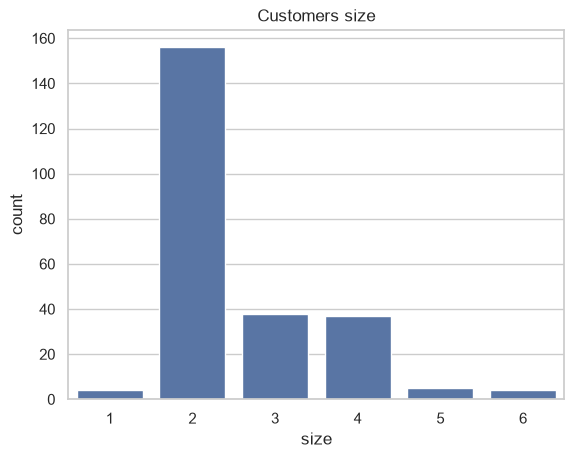

In [52]:
sns.countplot(data=df, x="size")
plt.title("Customers size")
plt.show()

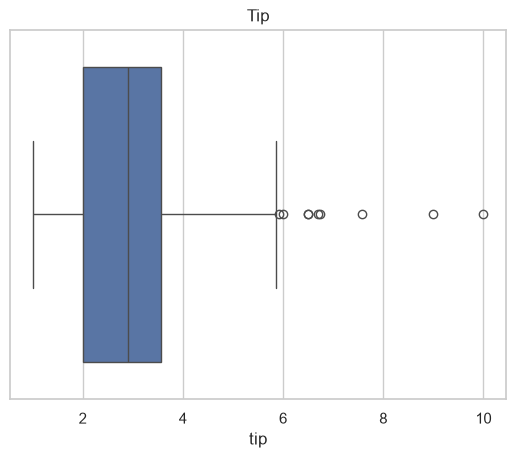

In [57]:
sns.boxplot(data=df, x="tip")
plt.title("Tip")
plt.show()

In [61]:
q1 = df["tip"].quantile(0.25)
q3 = df["tip"].quantile(0.75)
iqr = q3 - q1
high = q3 + 1.5 * iqr

print("Q1:", q1, " Q3:", q3, " IQR:", round(iqr, 1))
print("Above", round(high, 1), "is an outlier")

outliers = df[df["tip"] > high]
print("Number of outliers:", len(outliers))
outliers.sort_values("tip", ascending=False).head(9)

Q1: 2.0  Q3: 3.5625  IQR: 1.6
Above 5.9 is an outlier
Number of outliers: 9


,total_bill,tip,sex,smoker,day,time,size,total_amount
170,50.81,10.00,Male,Yes,Sat,Dinner,3,60.81
212,48.33,9.00,Male,No,Sat,Dinner,4,57.33
23,39.42,7.58,Male,No,Sat,Dinner,4,47.00
59,48.27,6.73,Male,No,Sat,Dinner,4,55.00
141,34.30,6.70,Male,No,Thur,Lunch,6,41.00
214,28.17,6.50,Female,Yes,Sat,Dinner,3,34.67
183,23.17,6.50,Male,Yes,Sun,Dinner,4,29.67
47,32.40,6.00,Male,No,Sun,Dinner,4,38.40
239,29.03,5.92,Male,No,Sat,Dinner,3,34.95


Text(0.5, 1.0, 'Correlation with tip')

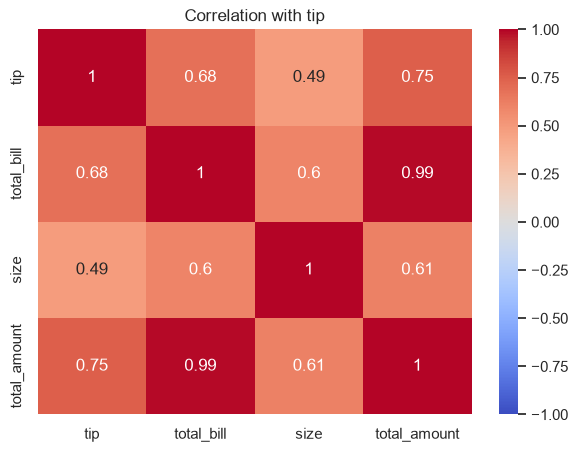

In [ ]:
cols = ["tip", "total_bill", "size", "total_amount"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[cols].corr().round(2), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation with tip")